In [1]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
import numpy as np
import suite2p
import mbo_utilities as mbo
import fastplotlib as fpl
from copy import deepcopy
import lbm_suite2p_python as lsp

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),Intel(R) Graphics (RPL-P),IntegratedGPU,Vulkan,Mesa 24.0.3-1pop1~1711635559~22.04~7a9f319
❗ limited,"llvmpipe (LLVM 15.0.7, 256 bits)",CPU,Vulkan,Mesa 24.0.3-1pop1~1711635559~22.04~7a9f319 (LLVM 15.0.7)
❌,Mesa Intel(R) Graphics (RPL-P),IntegratedGPU,OpenGL,4.6 (Core Profile) Mesa 24.2.8-1~bpo12+1pop1~1744225826~22.04~b077665


In [2]:
scan = mbo.read_scan("D://demo//raw")
mbo.save_as(scan, "D://demo//assembled", ext='tif')

Reading tiff series data...
Reading tiff pages...
Raw tiff fully read.


Saving plane :   0%|          | 0/252 [00:00<?, ?it/s]

Time elapsed: 0 minutes 20 seconds.


In [3]:
input_files = mbo.get_files("/home/flynn/lbm_data/assembled", 'tif')
input_files[:2]  # first 2 files

['/home/flynn/lbm_data/assembled/plane_01.tif',
 '/home/flynn/lbm_data/assembled/plane_02.tif']

## Run a single z-plane

Below are the defaults, with a single path to an [assembled](https://millerbrainobservatory.github.io/mbo_utilities/assembly.html#save-assembled-files) scanimage tiff.

By default, metadata is used to pre-fill 'dx', 'dy', 'fs', and some output-related parameters.

User-defined options will take precendence to the defaults.

In [4]:
new_ops = {"tau": 0.35}

save_path = r"/home/flynn/lbm_data/mactest"  # will be created if it doesn't exist
output_ops = lsp.run_plane(
    input_path=input_files[0],            
    save_path=save_path,
    ops=new_ops,         # default is None
    keep_raw=True,       # default is False
    keep_reg=True,       # default is True
    force_reg=False,     # default is False
    force_detect=False,  # default is False
)

Writing raw binary to /home/flynn/lbm_data/mactest/plane1/data_raw.bin
Applying user ops: {'tau': 0.35}
NOTE: applying default /home/flynn/.suite2p/classifiers/classifier_user.npy
----------- REGISTRATION
Reference frame, 16.50 sec.
Registered 500/1437 in 18.38s
Registered 1000/1437 in 33.37s
Registered 1437/1437 in 43.09s
----------- Total 64.60 sec
----------- ROI DETECTION
Binning movie in chunks of length 06
Binned movie of size [239,442,442] created in 0.41 sec.
NOTE: estimated spatial scale ~6 pixels, time epochs 1.00, threshold 5.00 
0 ROIs, score=24.64
Detected 201 ROIs, 2.37 sec
After removing overlaps, 159 ROIs remain
----------- Total 3.03 sec.
----------- EXTRACTION
Masks created, 0.17 sec.
Extracted fluorescence from 159 ROIs in 1437 frames, 4.82 sec.
----------- Total 5.01 sec.
----------- CLASSIFICATION
['npix_norm', 'skew', 'compact']
----------- SPIKE DECONVOLUTION
----------- Total 0.02 sec.
Generating missing plots for plane1...
Plotting traces...
unknown label: unkn

## Preview outputs

In [16]:
from pprint import pprint
output_files = list(Path(save_path).rglob("*.*"))
pprint(output_files)

[WindowsPath('D:/demo/suite2p_results/plane1/data.bin'),
 WindowsPath('D:/demo/suite2p_results/plane1/data_raw.bin'),
 WindowsPath('D:/demo/suite2p_results/plane1/F.npy'),
 WindowsPath('D:/demo/suite2p_results/plane1/Fneu.npy'),
 WindowsPath('D:/demo/suite2p_results/plane1/iscell.npy'),
 WindowsPath('D:/demo/suite2p_results/plane1/max_projection_image.png'),
 WindowsPath('D:/demo/suite2p_results/plane1/model.npy'),
 WindowsPath('D:/demo/suite2p_results/plane1/ops.npy'),
 WindowsPath('D:/demo/suite2p_results/plane1/rastermap.png'),
 WindowsPath('D:/demo/suite2p_results/plane1/segmentation.png'),
 WindowsPath('D:/demo/suite2p_results/plane1/shot_noise_distrubution.png'),
 WindowsPath('D:/demo/suite2p_results/plane1/spks.npy'),
 WindowsPath('D:/demo/suite2p_results/plane1/stat.npy'),
 WindowsPath('D:/demo/suite2p_results/plane1/traces.png')]



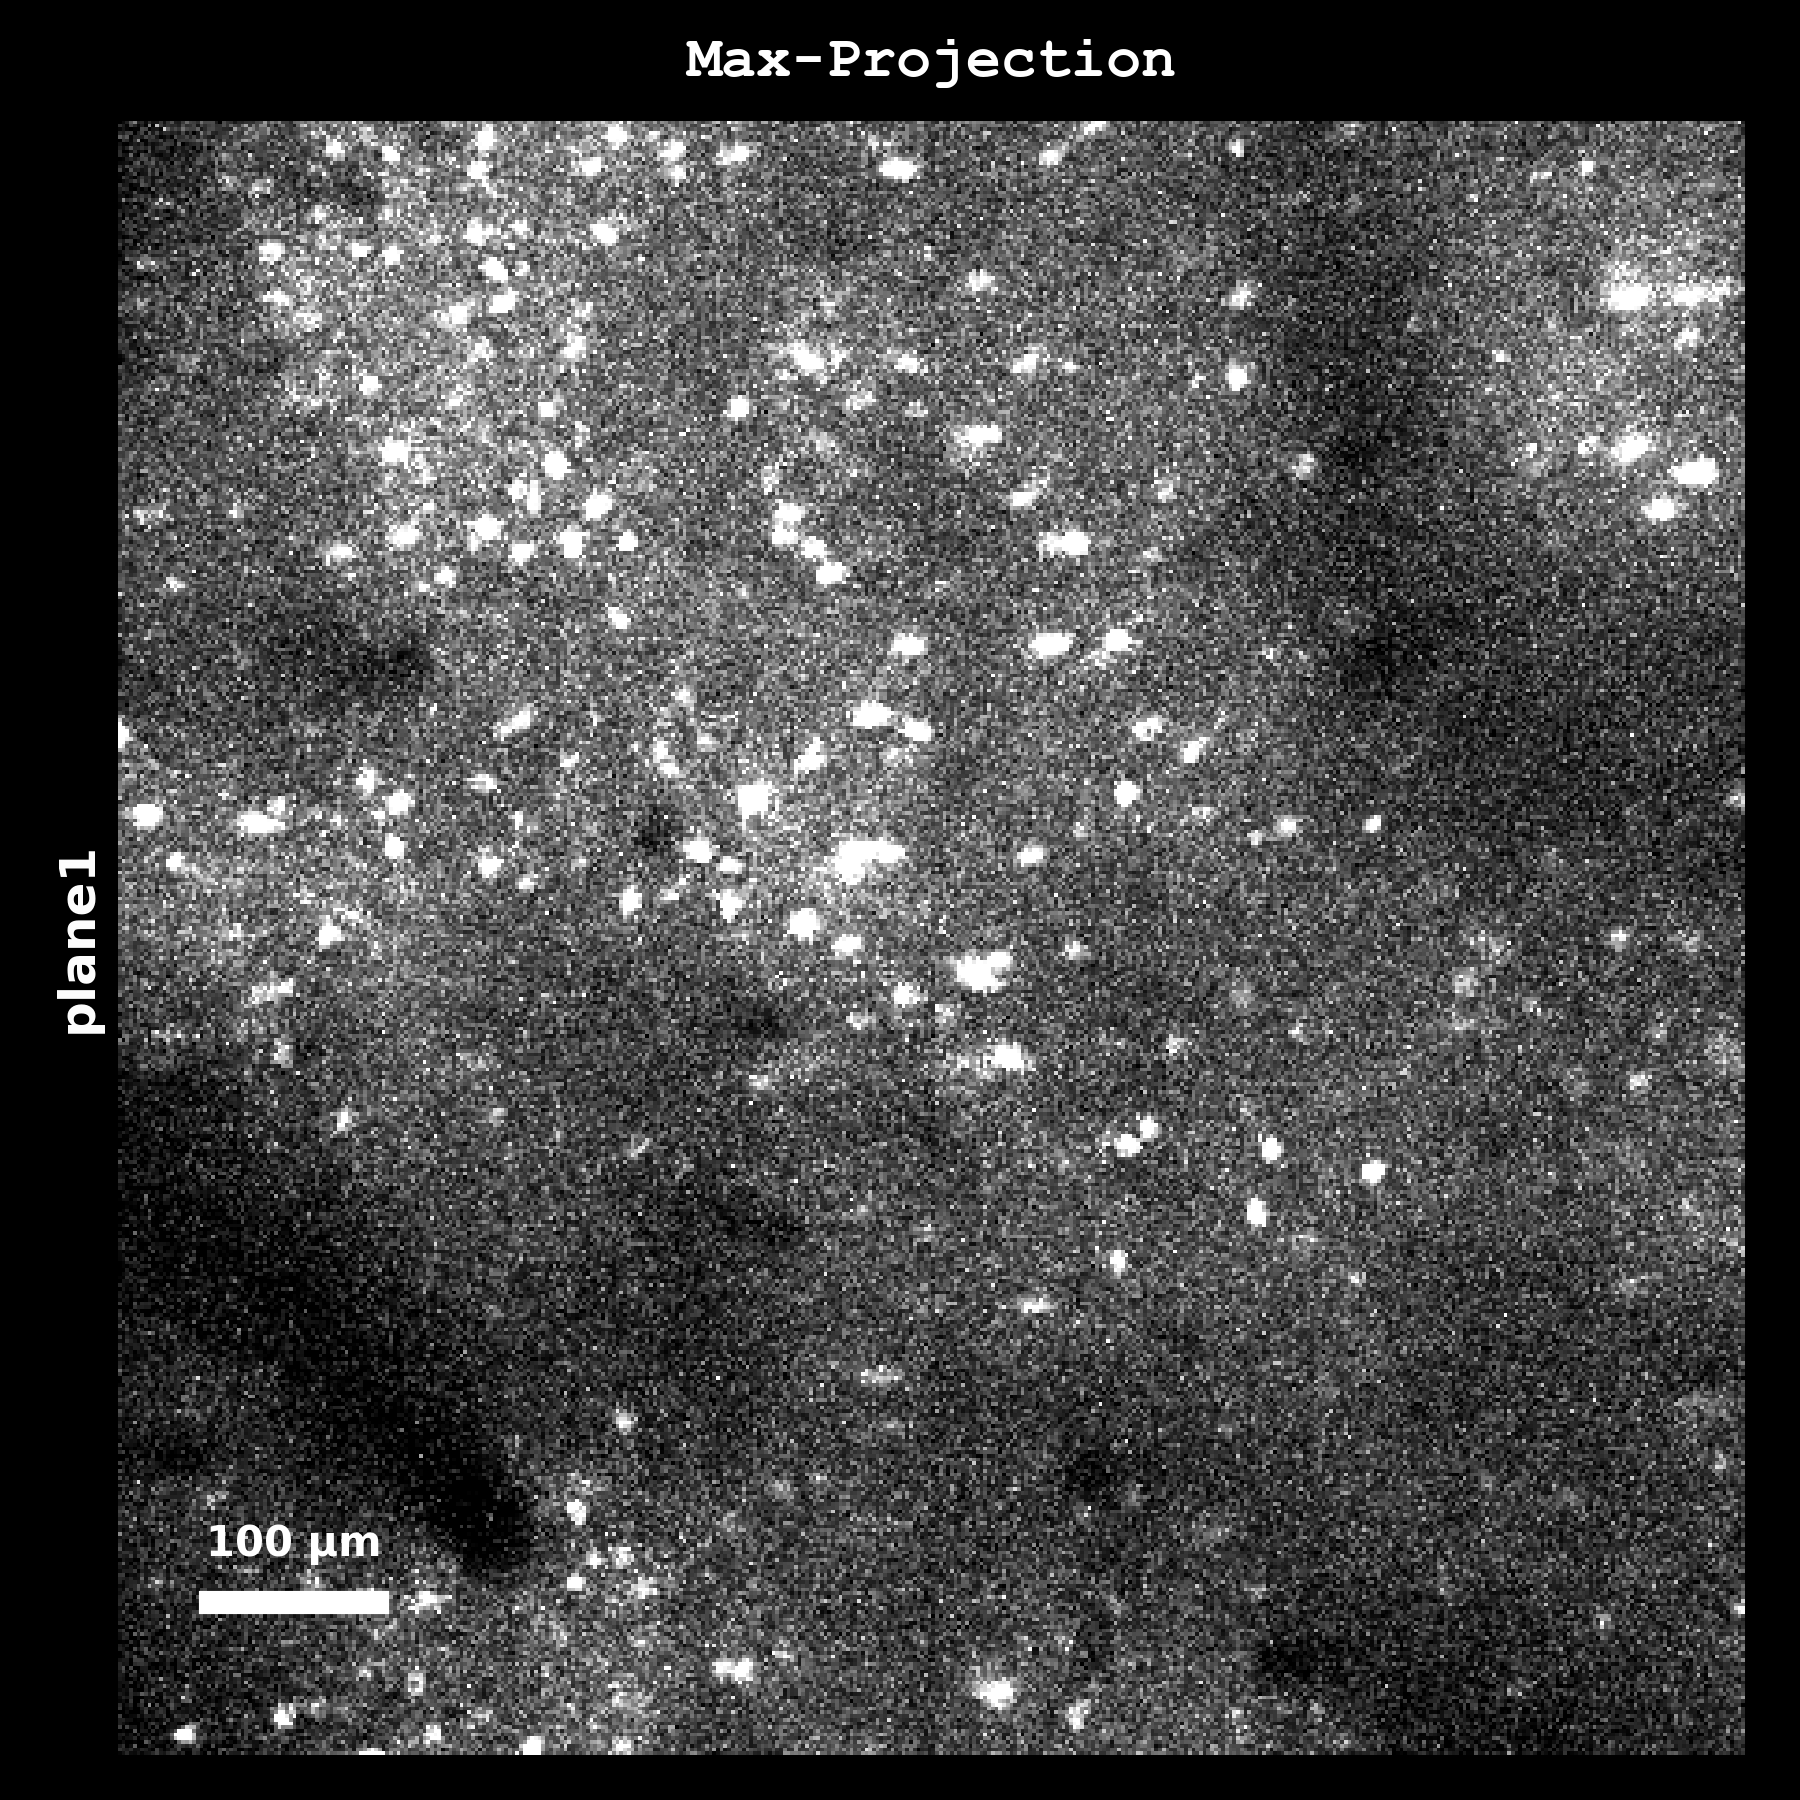
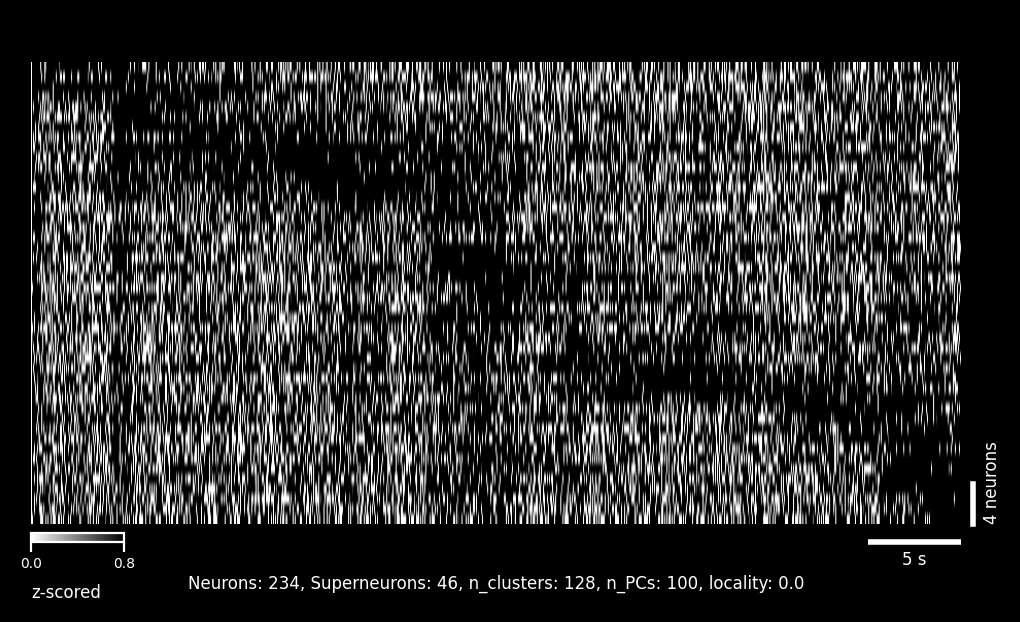
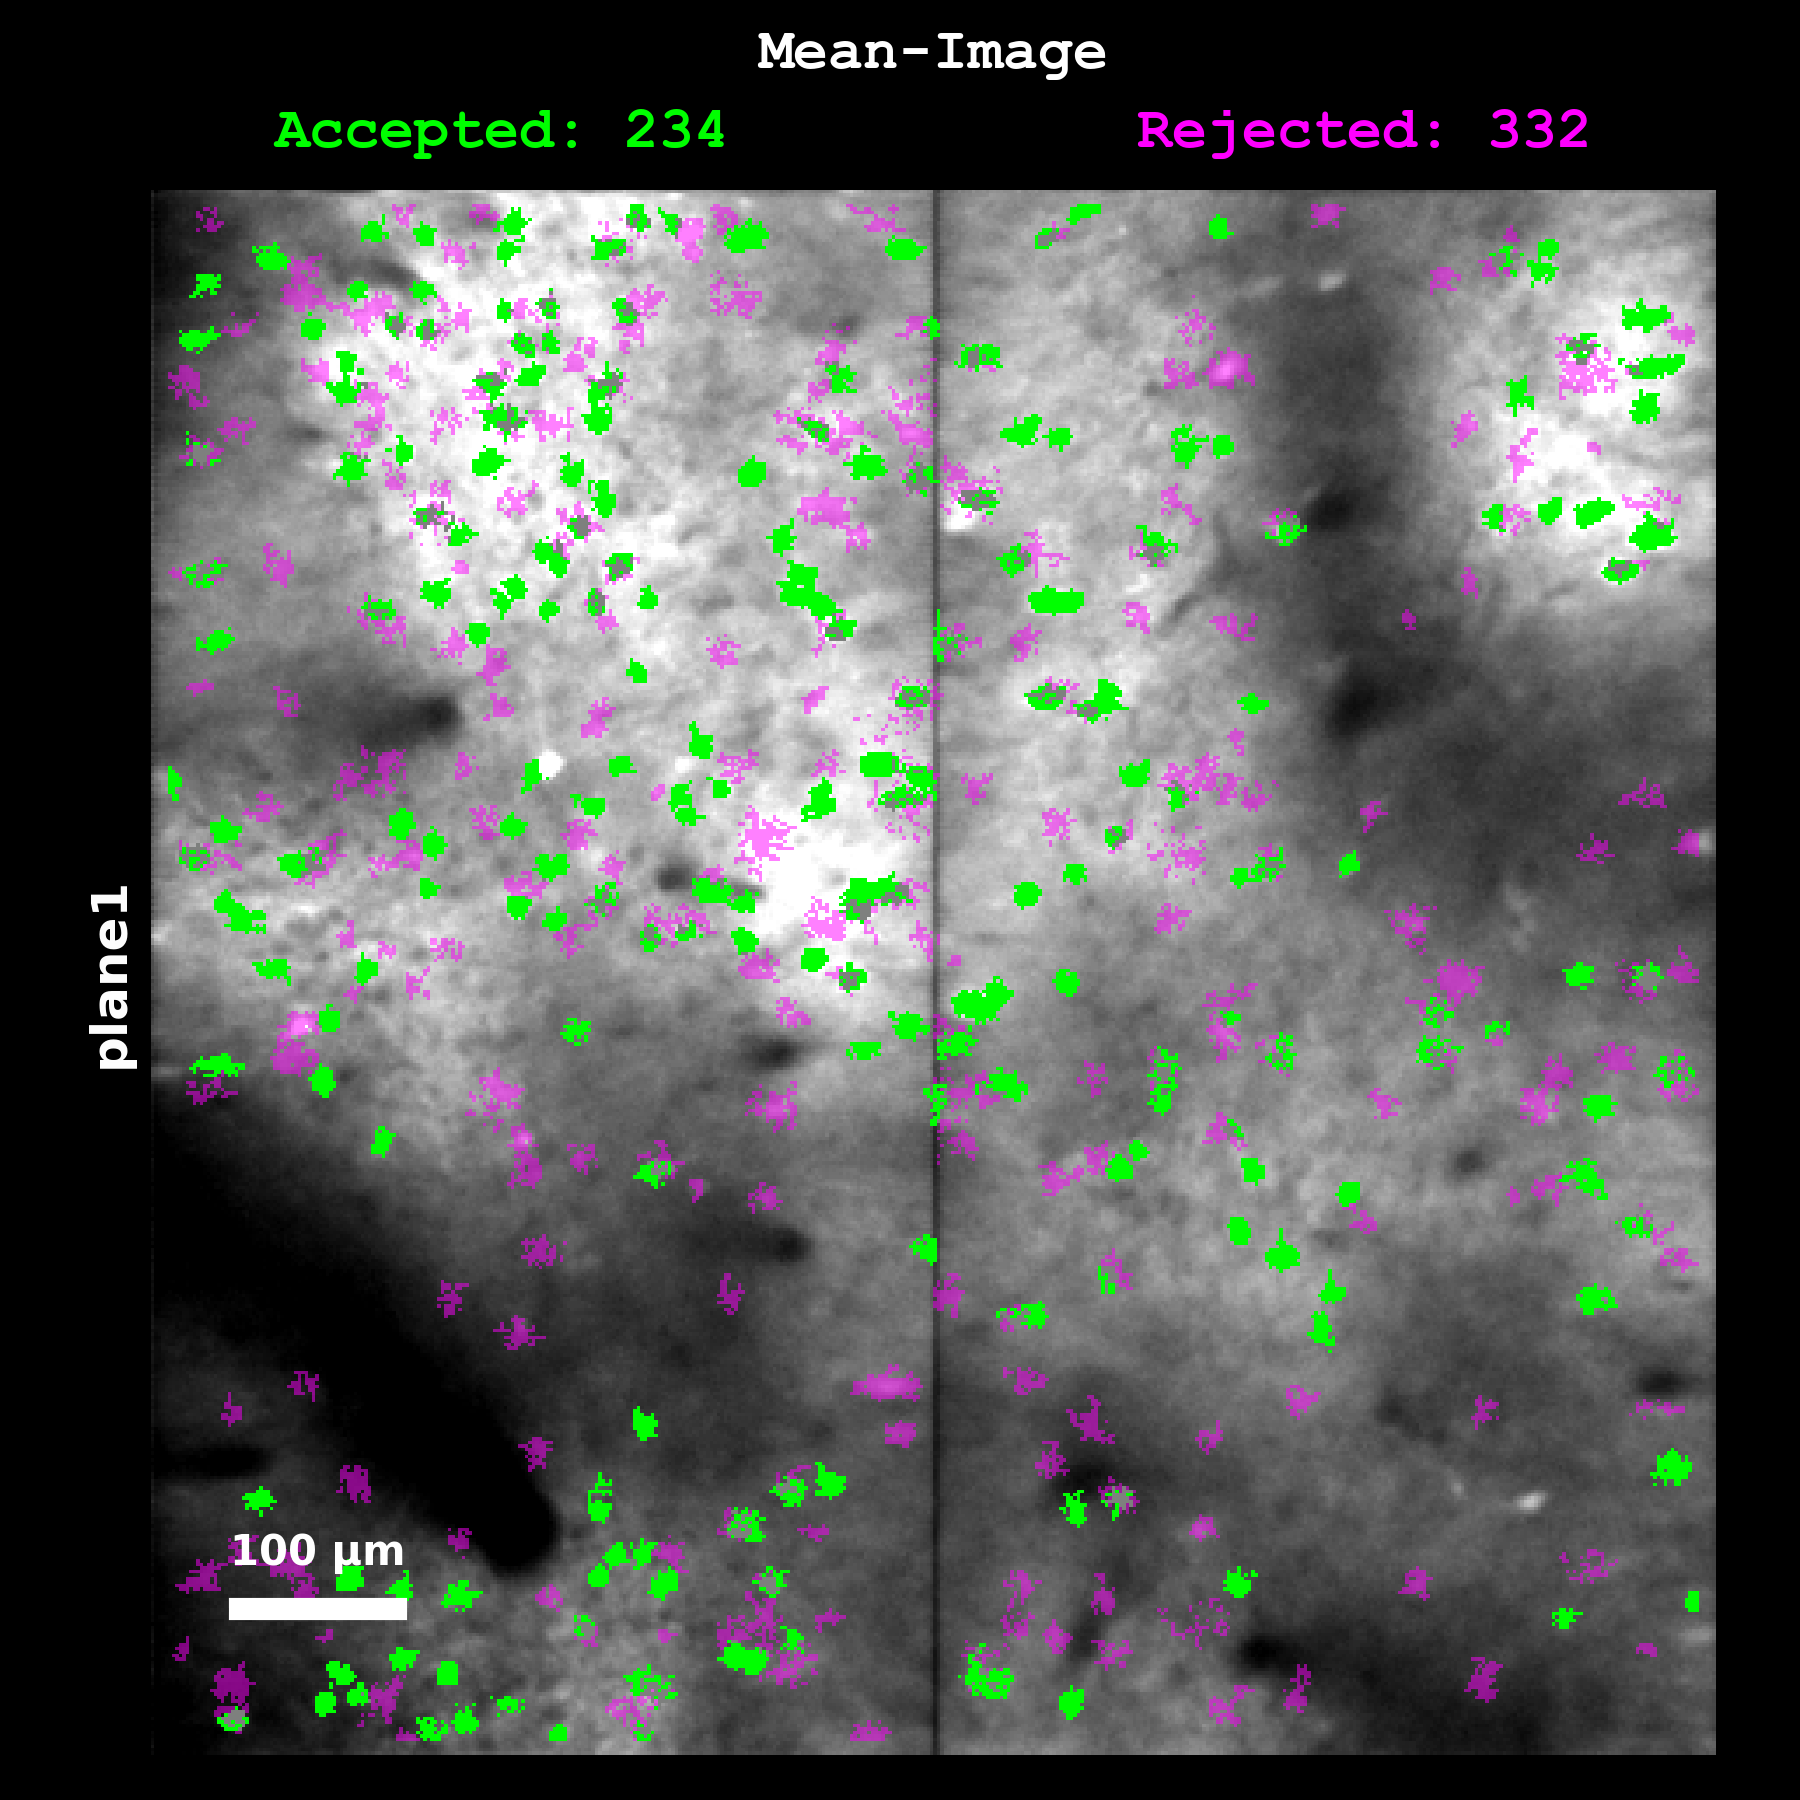
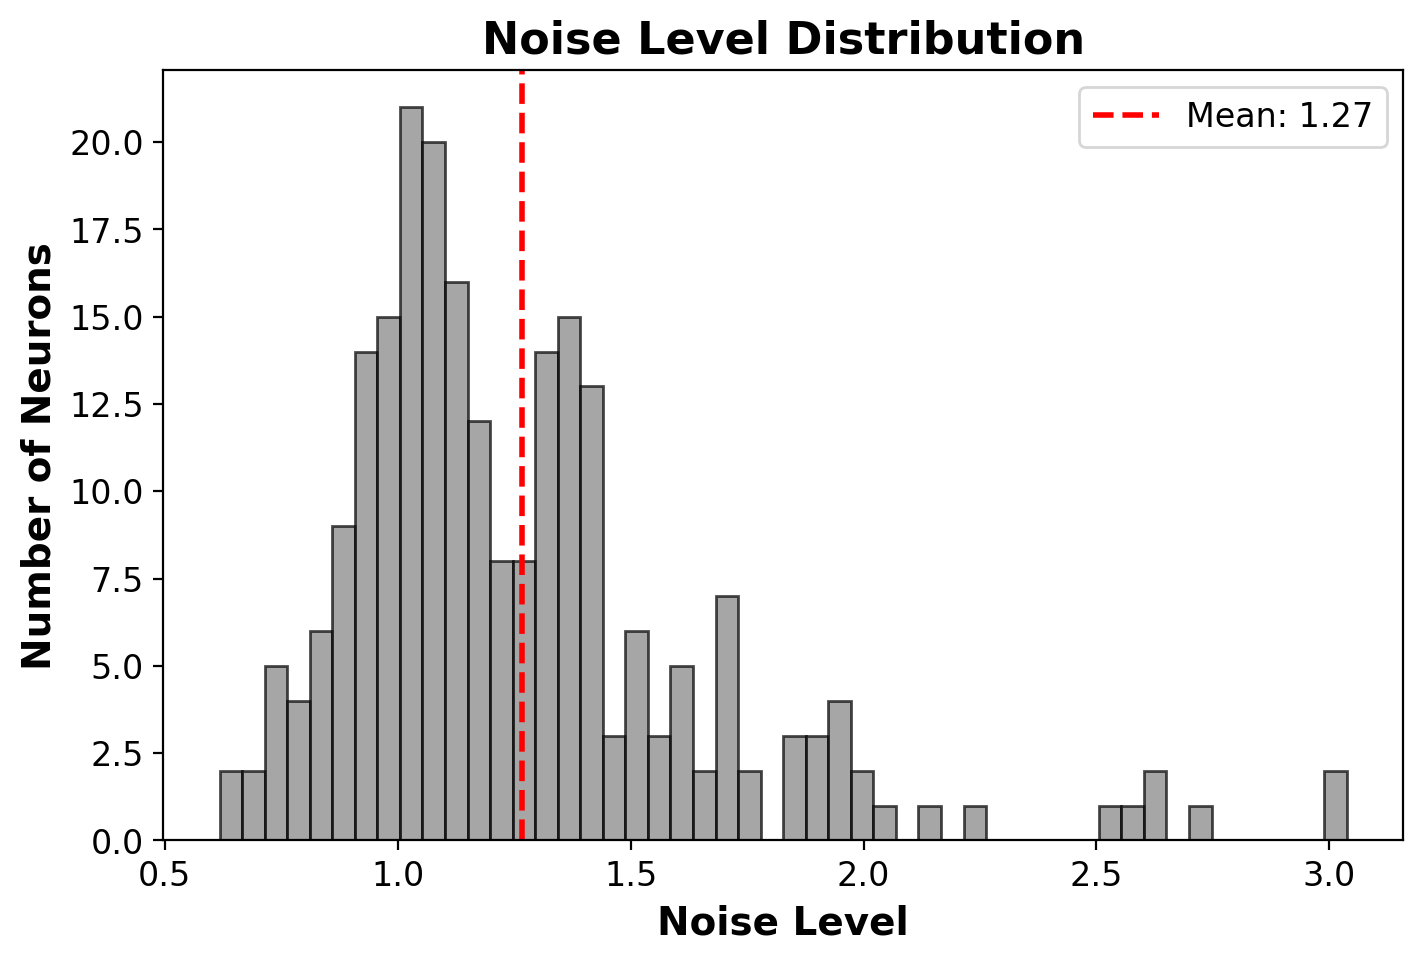
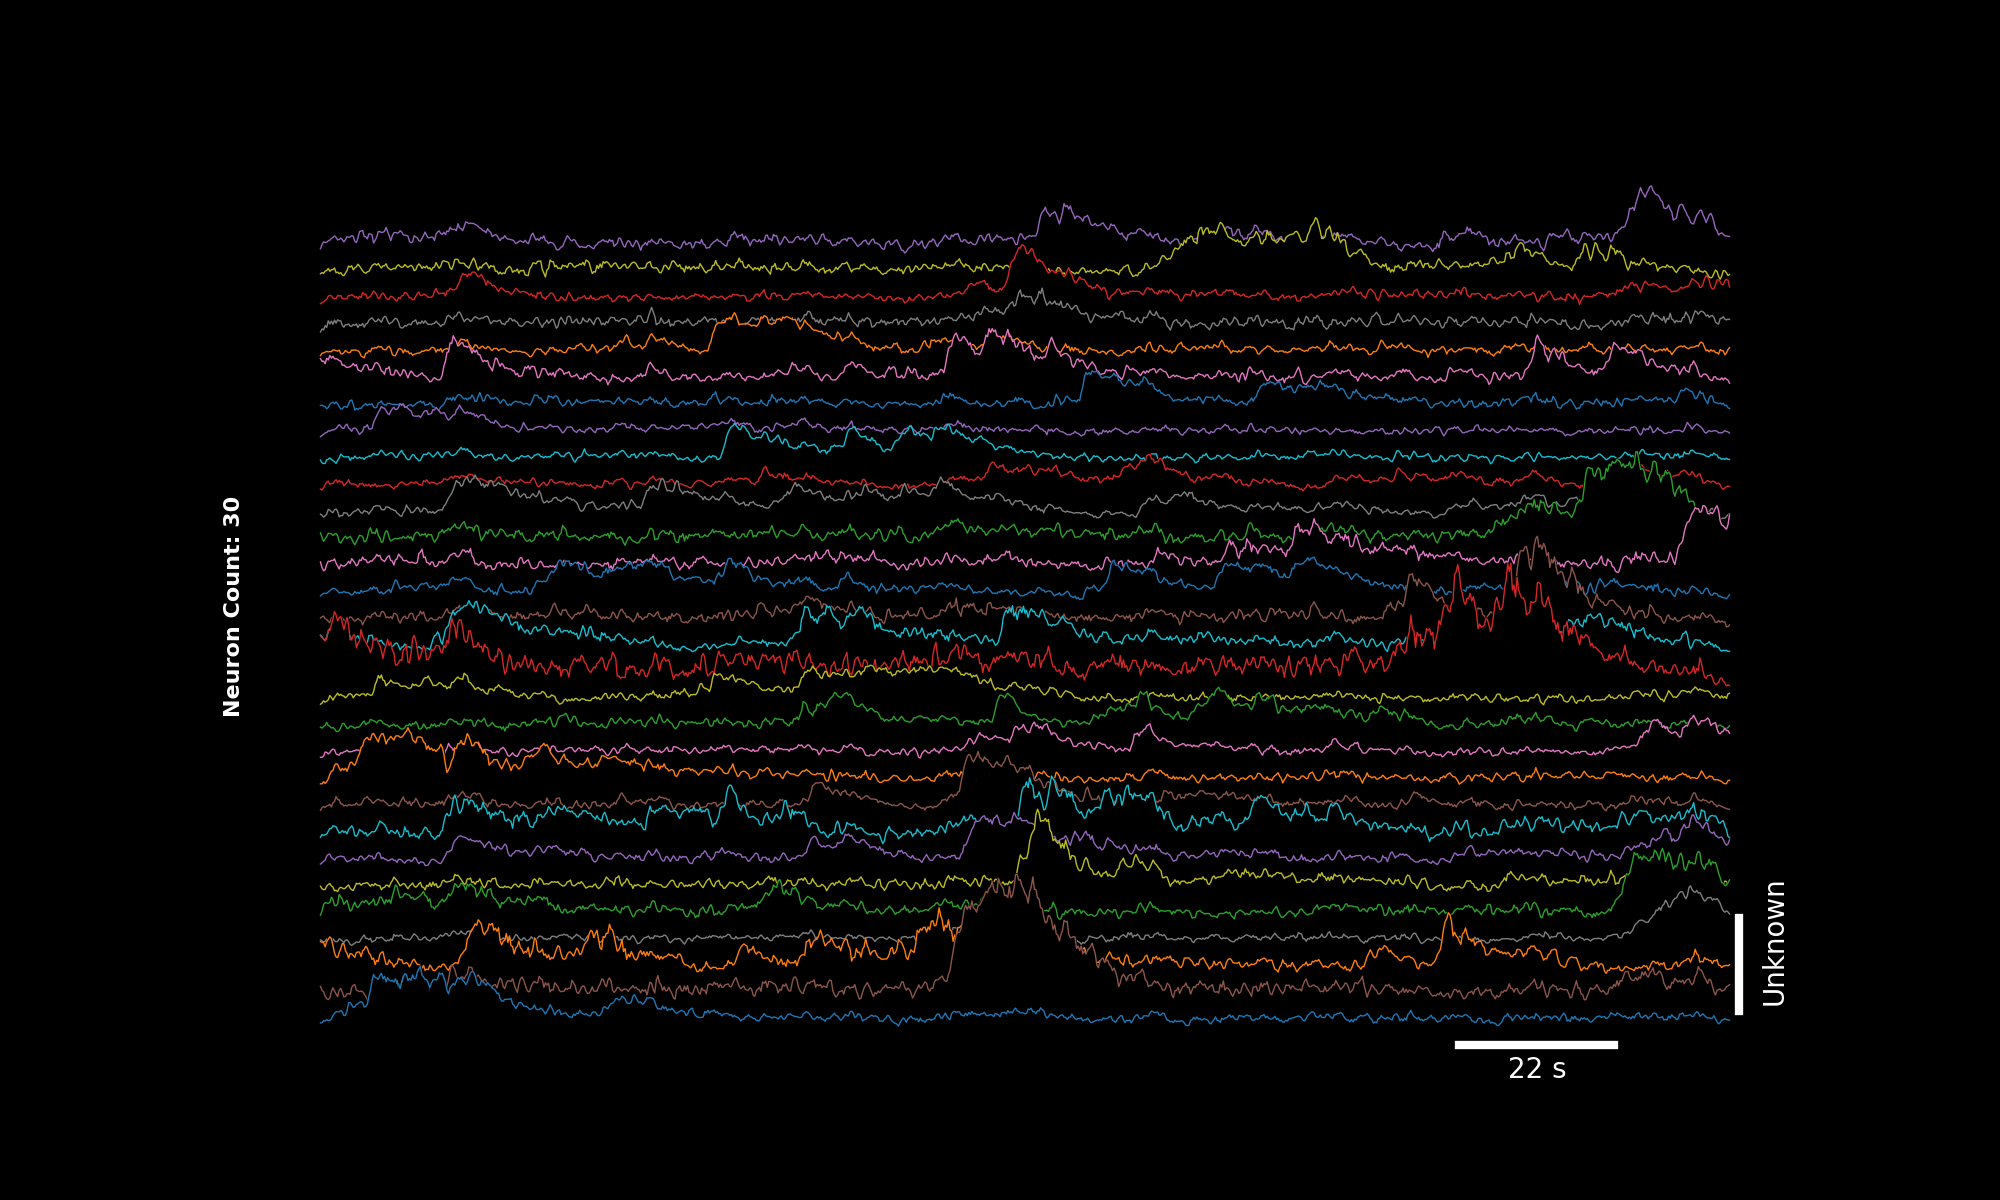

In [14]:
## This is just to show the default outputs in jupyter for convenience
from IPython.display import display, HTML
from pathlib import Path
import base64

def image_to_base64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

png_files = list(Path(save_path).rglob("*.png"))

html = "<div style='display: flex; gap: 12px;'>"
for p in png_files:
    img_b64 = image_to_base64(p)
    html += f"""
    <div style='text-align: center'>
        <img src='data:image/png;base64,{img_b64}' width='400px'>
        <div style='color: white; font-size: 12px'>{p.name}</div>
    </div>
    """
html += "</div>"

display(HTML(html))

In [22]:
statfile = mbo.get_files(save_path, 'stat', 2)[0]
statfile

'D:\\demo\\suite2p_results\\plane1\\stat.npy'

## Open Suite2p GUI 

- suite2p registration visualization: if you set `keep_reg` = True, you can view the raw movie with suite2p -> registration -> view registration binary
- if you set `keep_raw` = True, the checkbox "view raw binary" will show a side-by-side of your registered / raw movies
- if you have > 1500 frames, click suite2p -> registration -> view registration metrics, to view top/bottom PC's to look for activity (good) or motion (bad)

In [ ]:
from suite2p import gui
gui.run(statfile=statfile)

## Run volume
- acts the same as `run_plane` but accepts a list of files and creates some visualizations / statistics from the collated z-planes.

In [ ]:
lsp.run_volume(
    input_files=input_files,
    save_path=save_path,
    ops={"two_step_registration": True, "delete_bin": True},
)

Processing Planes:   0%|          | 0/14 [00:00<?, ?it/s]

Processing D:\demo\assembled\plane_01.tif ---------------
Applying user ops: {'two_step_registration': True, 'delete_bin': True}
NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
----------- REGISTRATION
Reference frame, 6.61 sec.
Registered 500/903 in 7.44s
Registered 903/903 in 13.59s
----------- Total 21.53 sec
Generating missing plots for plane1...
Plotting traces...
unknown label: unknown
Plotting noise distribution...
Computing rastermap model...
2025-05-13 16:36:15,923 [INFO] normalizing data across axis=1
2025-05-13 16:36:15,925 [INFO] projecting out mean along axis=0
2025-05-13 16:36:15,925 [INFO] data normalized, 0.00sec
2025-05-13 16:36:15,925 [INFO] sorting activity: 234 valid samples by 903 timepoints
2025-05-13 16:36:15,976 [INFO] n_PCs = 128 computed, 0.05sec
2025-05-13 16:36:16,054 [INFO] 100 clusters computed, time 0.13sec
2025-05-13 16:36:23,741 [INFO] clusters sorted, time 7.82sec
2025-05-13 16:36:23,913 [INFO] clusters upsampled, time 7.99